In [1]:
from loaders import load_tisch, load_sept, load_bible, load_references
import numpy as np
import pandas as pd

In [2]:
bible = load_bible()
bible.index = np.arange(len(bible))
references = load_references()

In [3]:
bible_books = bible["book"].unique()
book_map = pd.Series(np.arange(1, len(bible_books) + 1), index=bible_books)
bible["booknum"] = book_map[bible["book"]].values

In [4]:
references["obook"] = bible.iloc[references["ostart"]]["book"].values
references["nbook"] = bible.iloc[references["nstart"]]["book"].values

In [5]:
ot = bible.query("booknum < 40")
nt = bible.query("booknum >= 40")

In [6]:

ot_books = pd.Series(ot["book"].unique())
ot_books.index = ot_books
nt_books = pd.Series(nt["book"].unique())
nt_books.index = nt_books

In [7]:
nt['reference_text'] = False
for obook in ot_books:
    nt[f"reference_{obook}"] = False

for ostart, nstart, nend in references[["ostart", "nstart", "nend"]].values:
    nt.loc[nstart : nend - 1, "reference_text"] = True
    obook = ot.iloc[ostart]['book']
    nt.loc[nstart : nend - 1, f"reference_{obook}"] = True

/tmp/ipykernel_16395/3806089295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nt['reference_text'] = False
/tmp/ipykernel_16395/3806089295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nt[f"reference_{obook}"] = False
/tmp/ipykernel_16395/3806089295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

In [8]:
use_counts = (
    nt.groupby("book")
    .apply(
        lambda book: ot_books.apply(lambda obook: book[f'reference_{obook}'].sum()),
        include_groups=False,
    )
    .reindex(nt_books, columns=ot_books)
    .fillna(0)
    .astype(int)
)
total_quoted = nt.groupby("book")["reference_text"].sum().loc[use_counts.index]
book_lens = nt["book"].value_counts().loc[use_counts.index]

In [9]:
import seaborn as sns
sns.set_theme(style='white', context='paper')

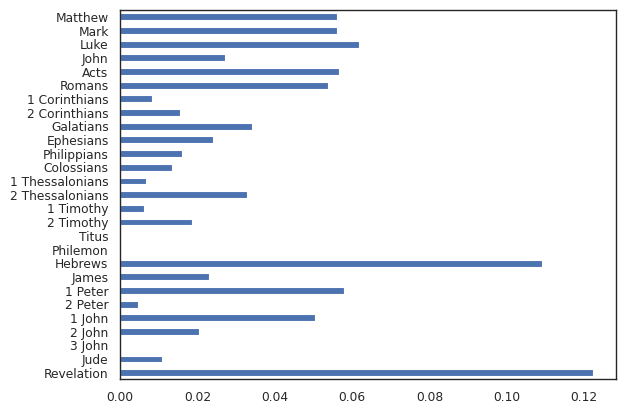

In [10]:
use_props = use_counts / book_lens.values[:, None]
total_props = total_quoted / book_lens.values
total_props[::-1].plot.barh(ylabel='');

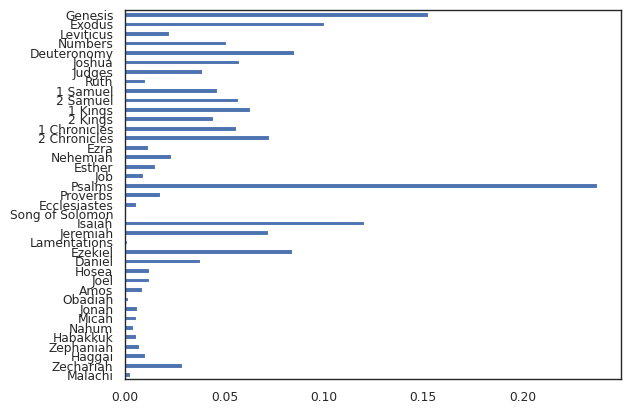

In [11]:
use_props.T.sum(axis=1)[::-1].plot.barh(ylabel='');

In [12]:
from sklearn.decomposition import PCA

In [13]:
import plotly.express as px

In [14]:
flat_props = use_props.values.flatten()
minv = flat_props[flat_props != 0].min()
pca = PCA(n_components=2)
logged_props = np.log(use_props+minv)

In [15]:
def plot(logged_props, books, scale, **kwargs):
    pca = PCA(n_components=2)
    new_comps = pca.fit_transform(logged_props)
    print(pca.explained_variance_ratio_.sum())

    new_df = pd.DataFrame(data=new_comps, columns=['x', 'y'])
    new_df['book'] = books
    new_df = new_df[['book', 'x', 'y']]

    ax = sns.scatterplot(
        new_df,
        x = 'y',
        y = 'x',
        **kwargs
    )
    for x, y, book in new_df[['x', 'y', 'book']].values:
        ax.annotate(book, (y, x))
    ax.set_axis_off()
    ax.figure.set_size_inches(scale * (new_df['y'].max() - new_df['y'].min()), scale * (new_df['x'].max() - new_df['x'].min()))
    return ax

In [16]:
from sklearn.cluster import AgglomerativeClustering

hcnt = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
labelsnt = hcnt.fit_predict(logged_props)
hcot = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labelsot = hcot.fit_predict(logged_props.T)

In [17]:
import matplotlib.pyplot as plt

0.6701637520037315


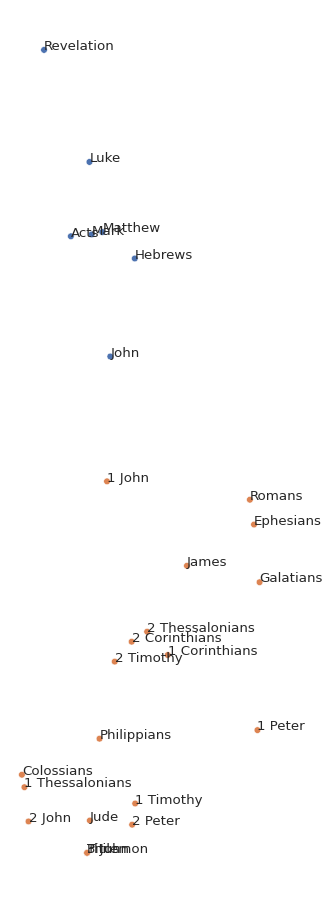

In [18]:
ax = plot(logged_props, nt_books.values, hue=labelsnt.astype(str), scale=.5)
ax.get_legend().remove()
plt.tight_layout()
# ax.figure.savefig('../Desktop/nt.png')

In [19]:
for label in range(3):
    print(*nt_books[labelsnt == label], sep=', ', end="\n")

Romans, 1 Corinthians, 2 Corinthians, Galatians, Ephesians, Philippians, Colossians, 1 Thessalonians, 2 Thessalonians, 1 Timothy, 2 Timothy, Titus, Philemon, James, 1 Peter, 2 Peter, 1 John, 2 John, 3 John, Jude
Matthew, Mark, Luke, John, Acts, Hebrews, Revelation



In [20]:
NT_clusters = ([nt_books[labelsnt == label] for label in range(3)])
print(NT_clusters[0].values)
print(NT_clusters[1].values)
print(NT_clusters[2].values)

['Romans' '1 Corinthians' '2 Corinthians' 'Galatians' 'Ephesians'
 'Philippians' 'Colossians' '1 Thessalonians' '2 Thessalonians'
 '1 Timothy' '2 Timothy' 'Titus' 'Philemon' 'James' '1 Peter' '2 Peter'
 '1 John' '2 John' '3 John' 'Jude']
['Matthew' 'Mark' 'Luke' 'John' 'Acts' 'Hebrews' 'Revelation']
[]


In [21]:
NT1 = bible[bible['book'].isin(NT_clusters[0])]
NT2 = bible[bible['book'].isin(NT_clusters[1])]
NT1['book'].value_counts()

book
Romans             7099
1 Corinthians      6815
2 Corinthians      4462
Ephesians          2413
Galatians          2223
1 John             2140
James              1739
1 Peter            1676
Philippians        1624
1 Timothy          1589
Colossians         1576
1 Thessalonians    1475
2 Timothy          1236
2 Peter            1100
2 Thessalonians     822
Titus               658
Jude                461
Philemon            336
2 John              246
3 John              217
Name: count, dtype: int64

In [22]:
NT1_references = references[references['nbook'].isin(NT_clusters[0])]
NT2_references = references[references['nbook'].isin(NT_clusters[1])]
NT1_references

,nstart,nlen,nend,ostart,olen,oend,obook,nbook
3022,558259,5,558264,10698,5,10703,Genesis,Romans
3023,558362,5,558367,2909,5,2914,Genesis,Romans
3024,558362,5,558367,448404,5,448409,Daniel,Romans
3025,558505,5,558510,466161,5,466166,Habakkuk,Romans
3026,558611,5,558616,152132,5,152137,Judges,Romans
...,...,...,...,...,...,...,...,...
3717,601972,5,601977,79523,5,79528,Numbers,1 John
3718,601986,5,601991,2883,5,2888,Genesis,1 John
3719,602117,5,602122,101878,5,101883,Deuteronomy,1 John
3720,602173,5,602178,426327,5,426332,Ezekiel,2 John


### What proportion Law, Prophetic, Writing?

In [23]:
ot_groups = {
    "Genesis": "Law",
    "Exodus": "Law",
    "Leviticus": "Law",
    "Numbers": "Law",
    "Deuteronomy": "Law",
    "Joshua": "Prophets",
    "Judges": "Prophets",
    "1 Samuel": "Prophets",
    "2 Samuel": "Prophets",
    "1 Kings": "Prophets",
    "2 Kings": "Prophets",
    "Isaiah": "Prophets",
    "Jeremiah": "Prophets",
    "Ezekiel": "Prophets",
    "Hosea": "Prophets",
    "Joel": "Prophets",
    "Amos": "Prophets",
    "Obadiah": "Prophets",
    "Jonah": "Prophets",
    "Micah": "Prophets",
    "Nahum": "Prophets",
    "Habakkuk": "Prophets",
    "Zephaniah": "Prophets",
    "Haggai": "Prophets",
    "Zechariah": "Prophets",
    "Malachi": "Prophets",
    "Psalms": "Writings",
    "Proverbs": "Writings",
    "Job": "Writings",
    "Song of Solomon": "Writings",
    "Ruth": "Writings",
    "Lamentations": "Writings",
    "Ecclesiastes": "Writings",
    "Esther": "Writings",
    "Daniel": "Writings",
    "Ezra": "Writings",
    "Nehemiah": "Writings",
    "1 Chronicles": "Writings",
    "2 Chronicles": "Writings"
}

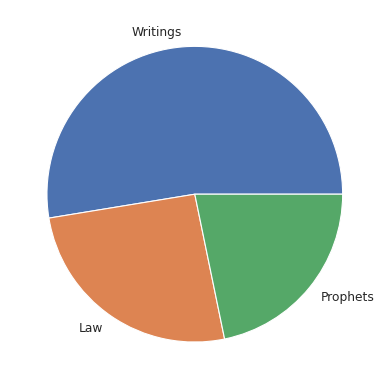

In [119]:
NT1_by_OT_genre = NT1_references['obook'].map(ot_groups)
NT1_referncing_OT_genres_props = NT1_by_OT_genre.value_counts() / len(NT1_by_OT_genre)
NT1_referncing_OT_genres_props.plot.pie(ylabel='');

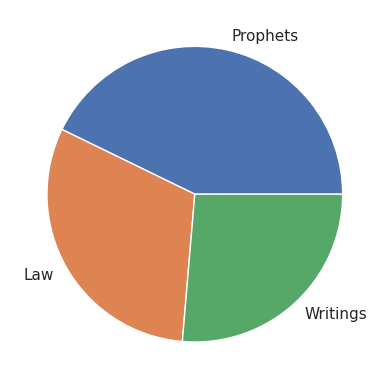

In [122]:
NT2_by_OT_genre = NT2_references['obook'].map(ot_groups)
NT2_referncing_OT_genres_props = NT2_by_OT_genre.value_counts() / len(NT2_by_OT_genre)
NT2_referncing_OT_genres_props.plot.pie(ylabel='');

In [124]:
import plotly.graph_objects as plotter

In [133]:
NT2_referncing_OT_genres_props.values

array([0.42781487, 0.30877274, 0.26341239])

In [134]:
px.pie(
    names =  NT2_referncing_OT_genres_props.keys(),
    values = NT2_referncing_OT_genres_props.values
)

In [135]:
px.pie(
    names =  NT1_referncing_OT_genres_props.keys(),
    values = NT1_referncing_OT_genres_props.values
)